KURUMSAL GÜVENLİK AĞI OPTİMİZASYON SONUÇLARI
Bağlantı: Server_Room  -- IT_Dept      | Maliyet: 2 bin $
Bağlantı: IT_Dept      -- Finance_Dept | Maliyet: 4 bin $
Bağlantı: Finance_Dept -- Marketing    | Maliyet: 6 bin $
Bağlantı: HR_Dept      -- Marketing    | Maliyet: 3 bin $
Bağlantı: Marketing    -- Research_Lab | Maliyet: 4 bin $
---------------------------------------------
Toplam Minimum Kurulum Maliyeti: 19 bin $
Görselleştirme kaydedildi: ..\results\network_visualization.png


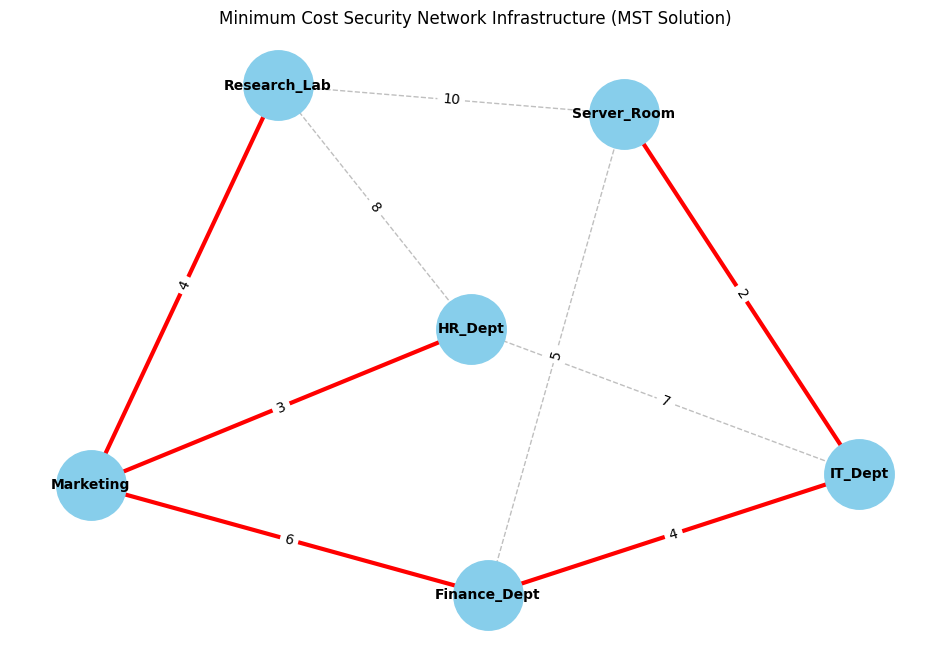

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

# Dosya yollarını çalışma dizinine göre ayarla
# Notebook (ipynb) için dosya yollarını ayarla
data_path = os.path.join('..', 'data', 'network_data.csv')
save_path = os.path.join('..', 'results', 'network_visualization.png')

# 1. Veriyi Yükleme
try:
    df = pd.read_csv(data_path)
except FileNotFoundError:
    print("Hata: 'data/network_data.csv' dosyası bulunamadı!")
    exit()

# 2. Graf Oluşturma
G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

# 3. MST (Minimum Spanning Tree) Algoritması - Kruskal
mst = nx.minimum_spanning_tree(G, algorithm='kruskal')

# 4. Sonuçları Terminale Yazdırma
print("="*45)
print("KURUMSAL GÜVENLİK AĞI OPTİMİZASYON SONUÇLARI")
print("="*45)
total_cost = 0
for u, v, d in mst.edges(data=True):
    print(f"Bağlantı: {u.ljust(12)} -- {v.ljust(12)} | Maliyet: {d['weight']} bin $")
    total_cost += d['weight']

print("-"*45)
print(f"Toplam Minimum Kurulum Maliyeti: {total_cost} bin $")
print("="*45)

# 5. Görselleştirme
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42) # Sabit yerleşim için seed

# Tüm ağ (arka plan)
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=1, edge_color='gray', style='dashed', alpha=0.5)

# MST (Seçilen Yollar)
nx.draw_networkx_edges(mst, pos, width=3, edge_color='red')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Minimum Cost Security Network Infrastructure (MST Solution)")
plt.axis('off')

# Sonucu Kaydet
plt.savefig(save_path)
print(f"Görselleştirme kaydedildi: {save_path}")
plt.show()